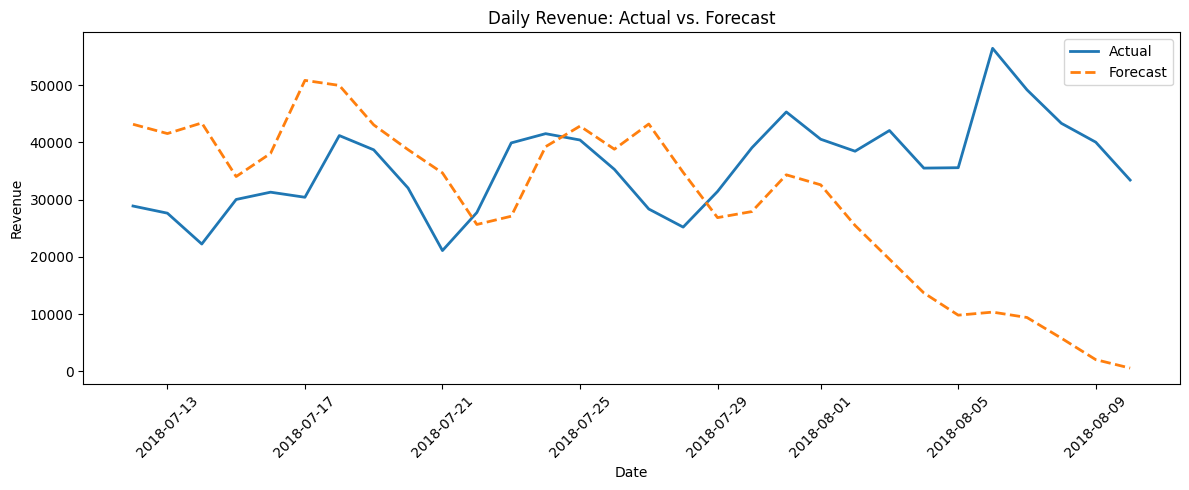

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load the Azure AutoML forecast output
with open("forecast_table.json", "r") as f:
    forecast = json.load(f)

# Use the first forecast horizon record
data = forecast["data"][0]

results = pd.DataFrame({
    "date": pd.to_datetime(data["time"][0][:len(data["y_pred"][0])]),
    "actual": data["y_true"][0][:len(data["y_pred"][0])],
    "predicted": data["y_pred"][0]
})

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    results["date"],
    results["actual"],
    label="Actual",
    linewidth=2
)

ax.plot(
    results["date"],
    results["predicted"],
    label="Forecast",
    linestyle="--",
    linewidth=2
)

ax.set_title("Daily Revenue: Actual vs. Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("forecast_chart.png", dpi=150)
plt.show()

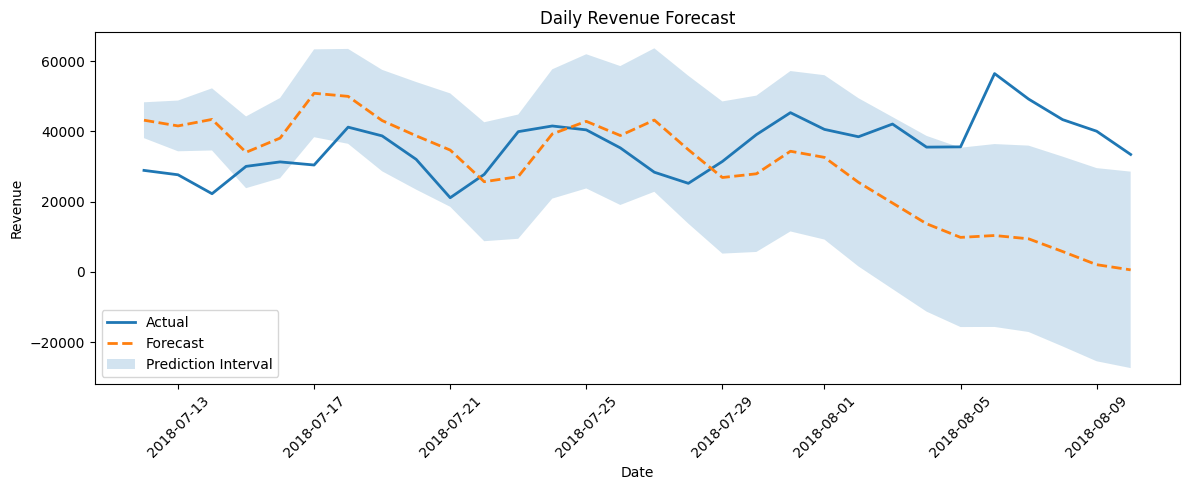

In [2]:
results["lower"] = data["PI_lower_bound"][0]
results["upper"] = data["PI_upper_bound"][0]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(results["date"], results["actual"],
        label="Actual", linewidth=2)

ax.plot(results["date"], results["predicted"],
        label="Forecast", linestyle="--", linewidth=2)

ax.fill_between(
    results["date"],
    results["lower"],
    results["upper"],
    alpha=0.2,
    label="Prediction Interval"
)

ax.set_title("Daily Revenue Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("forecast_chart.png", dpi=150)
plt.show()